In [1]:
#  1. Wczytanie i eksploracja danych

In [4]:
import pandas as pd

df = pd.read_csv("agaricus-lepiota.data", header=None, names=columns)

print("Rozmiar:", df.shape)

print("\nTypy zmiennych:\n", df.dtypes)

print("\nNulle:\n", df.isnull().sum())

print("\nHead:\n", df.head())

print("\nRozkład klas:\n", df['class'].value_counts())

print("\nStatystyki:\n", df.describe())

for col in ['odor', 'gill-color', 'cap-shape']:
    print(f"\n{col} – unikalne wartości:", df[col].unique())
    print(df[col].value_counts())


Rozmiar: (8124, 23)

Typy zmiennych:
 class                       object
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-root                  object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-below-ring      object
veil-type                   object
veil-color                  object
ring-number                 object
ring-type                   object
spore-print-color           object
population                  object
habitat                     object
dtype: object

Nulle:
 class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises       

In [5]:
# według dokumentacji "stalk-root: possible values are b = bulbous, c = club, u = cup, e = equal, z = rhizomorphs, r = rooted, ? = missing"

In [6]:
print(df['stalk-root'].value_counts())

stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64


In [ ]:
import numpy as np
df['stalk-root'].replace("?", np.nan, inplace=True)

df['stalk-root'].fillna(df['stalk-root'].mode()[0], inplace=True)

# uzupełnienie braków

In [10]:
# 2. Analiza eksploracyjna

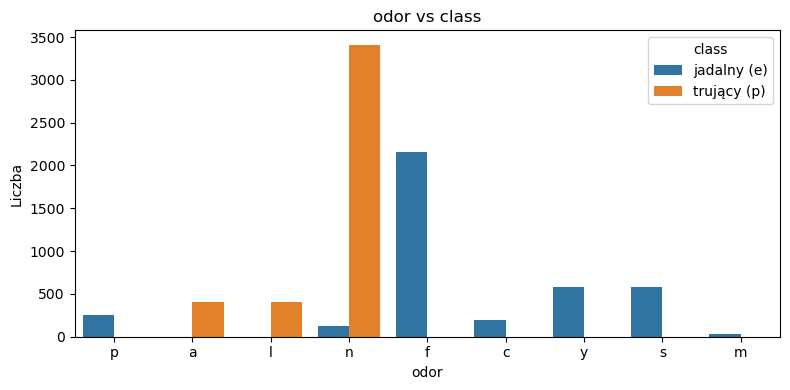

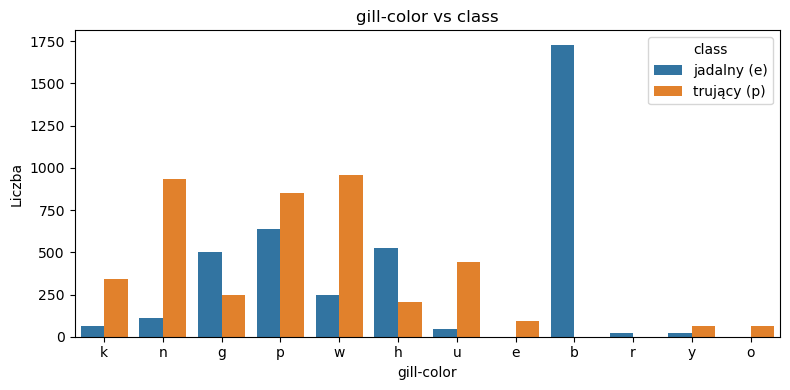

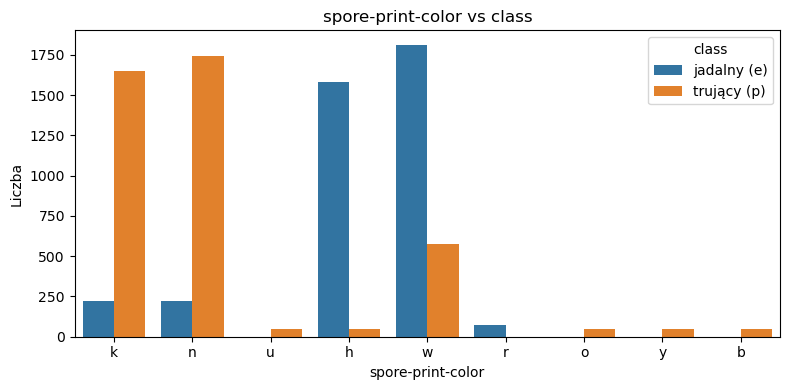

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['odor', 'gill-color', 'spore-print-color']

for feature in features:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=feature, hue='class', data=df)
    plt.title(f"{feature} vs class")
    plt.xlabel(feature)
    plt.ylabel("Liczba")
    plt.legend(title="class", labels=["jadalny (e)", "trujący (p)"])
    plt.tight_layout()
    plt.show()

In [34]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    denom = n * (min(k - 1, r - 1))
    # ten dodatek usuwa ostrzeżenie o dzieleniu przez 0
    if denom == 0:
        return np.nan
    return np.sqrt(chi2 / denom)

cramer_results = {}
for col in df.columns:
    if col != 'class':
        cramer_results[col] = cramers_v(df[col], df['class'])

cramer_df = cramer_df = (
    pd.DataFrame({
        'feature': cramer_results.keys(),
        'CramerV': cramer_results.values()
    })
    .sort_values(by='CramerV', ascending=False)
    .round(3)
    .reset_index(drop=True)
)
print(cramer_df.to_string(index=False))

                 feature  CramerV
                    odor    0.971
       spore-print-color    0.753
              gill-color    0.681
               ring-type    0.603
stalk-surface-above-ring    0.588
stalk-surface-below-ring    0.575
               gill-size    0.540
  stalk-color-above-ring    0.525
  stalk-color-below-ring    0.515
                 bruises    0.501
              population    0.487
                 habitat    0.440
              stalk-root    0.361
            gill-spacing    0.348
               cap-shape    0.246
               cap-color    0.218
             ring-number    0.215
             cap-surface    0.197
              veil-color    0.153
         gill-attachment    0.128
             stalk-shape    0.102
               veil-type      NaN


In [19]:
# odor ma najsilniejszą zależność, przesądza ona o klasie, spore=print-colore również bardzo istotna, przyda się do klasyfikacji.

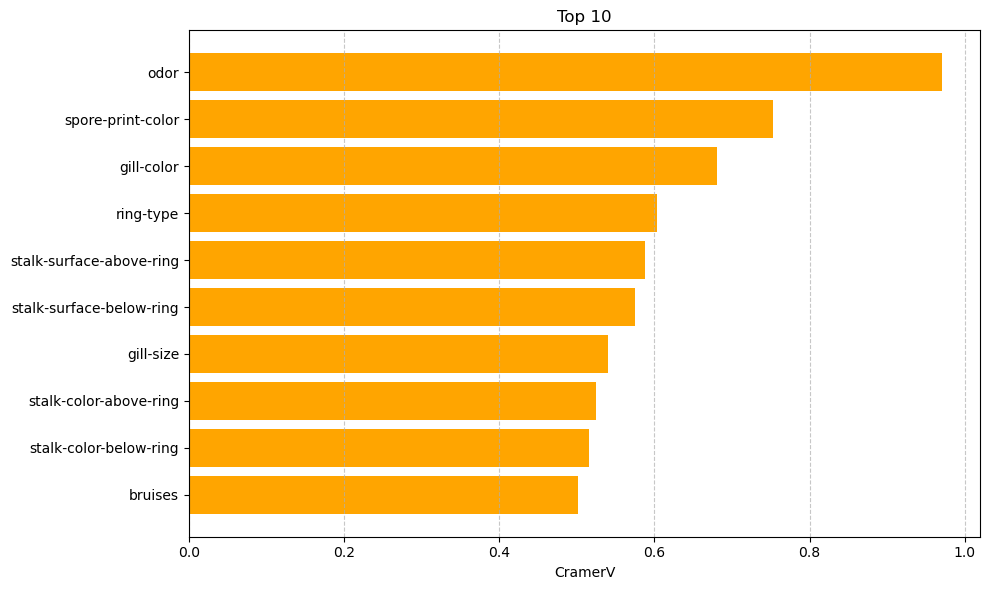

In [36]:
cramer_plot = cramer_df.dropna().sort_values(by='CramerV', ascending=True).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(cramer_plot['feature'], cramer_plot['CramerV'], color='orange')
plt.xlabel("CramerV")
plt.title("Top 10")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [37]:
# 3. Przygotowanie danych

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

df = df.drop(columns=["veil-type"])

X = df.drop("class", axis=1)
y = df["class"].map({'e': 0, 'p': 1})  # 0 = jadalny, 1 = trujący

In [41]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train rozkład:\n", y_train.value_counts(normalize=True))

X_train: (6499, 115)
X_test : (1625, 115)
y_train rozkład:
 class
0    0.517772
1    0.482228
Name: proportion, dtype: float64


In [43]:
# 4.Budowa modeli klasyfikacyjnych

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear'), #Stabilny dla danych binarnych
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42), #Ogranicza nadmierne dopasowanie
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42), #Równowaga między dokładnością i czasem
    "Naive Bayes": CategoricalNB(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42) #Typowe parametry startowe
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

In [55]:
# 5. Ocena modeli

In [49]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, RocCurveDisplay
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4),
        "Confusion Matrix": cm
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score       Confusion Matrix
Logistic Regression    1.0000     1.0000  1.0000    1.0000   [[843, 0], [0, 782]]
      Decision Tree    1.0000     1.0000  1.0000    1.0000   [[843, 0], [0, 782]]
      Random Forest    1.0000     1.0000  1.0000    1.0000   [[843, 0], [0, 782]]
        Naive Bayes    0.9397     0.9803  0.8926    0.9344 [[829, 14], [84, 698]]
  Gradient Boosting    1.0000     1.0000  1.0000    1.0000   [[843, 0], [0, 782]]


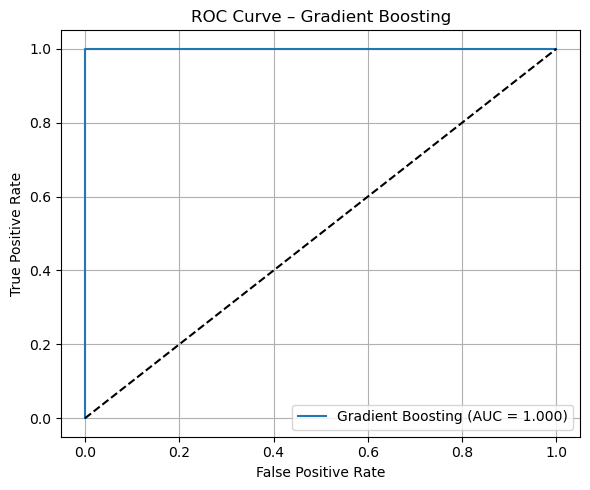

In [50]:
best_model = models["Gradient Boosting"]
y_score = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Gradient Boosting")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
# Wszystkie modele oprócz Naive Bayes dają perfekcyjne wyniki. Powodów wyniku 1.0 może być kilka:
# Zbior danych jest łatwy do klasyfikacji.
# Dane są idealnie rozdzielne – np. cecha odor prawie jednoznacznie określa klasę.
# Modele uczące się wzorców bez problemu wychwytują reguły które są proste i jednoznaczne.
# Overfitting nie występuje, ponieważ testowe dane też są perfekcyjnie zklasyfikowane.
# Naive Bayes jako jedyny nie dał perfekcyjnych wyników – ponieważ zakłada niezależność cech, a tu cechy są współzależne (np. odor + gill-color).

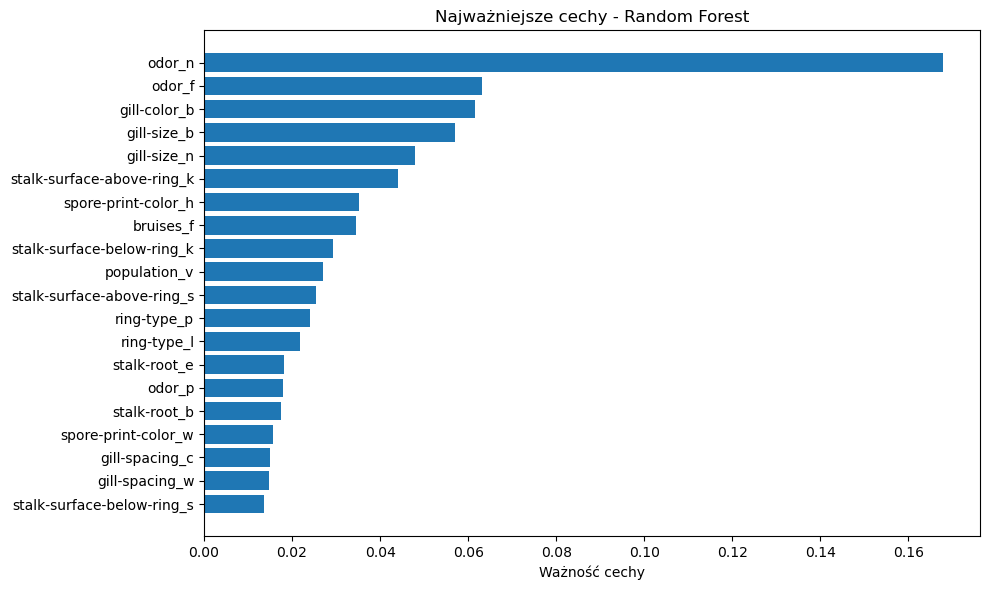

In [56]:
feature_names = encoder.get_feature_names_out(input_features=X.columns)

rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False).head(20)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"][::-1], feat_imp["importance"][::-1])
plt.xlabel("Ważność cechy")
plt.title("Najważniejsze cechy - Random Forest")
plt.tight_layout()
plt.show()

In [58]:
# Najważniejszymi cechami są odor (co potwierdza CramerV), gill-color i size. 
# Oznacza to, że nieporównywalnie większy wpływ na jadalność grzybów ma ich zapach a nie kolor "spores".

In [60]:
# Konsekwencje błędów:
# False Positive (FP)	Grzyb jadalny zaklasyfikowany jako trujący - niski koszt, strata potencjalnego posiłku
# False Negative (FN)	Grzyb trujący uznany za jadalny- wysokie ryzyko zdrowotne lub śmiertelne

# Wnioskując z konsekwencji: 
# Recall dla klasy trującej powinien być jak najwyższy - model nie może przegapić trujących.
# Naive Bayes był z tego powodu najgorszy, bo miał 84 FN – czyli 84 trujące grzyby zaklasyfikował jako jadalne.

In [ ]:
# 7. Wnioski

In [61]:
#Na podstawie metryk, cztery modele:
    # Logistic Regression
    # Decision Tree
    # Random Forest
    # Gradient Boosting
# osiągnęły perfekcyjne wyniki: 1.0
# Random Forest lub Gradient Boosting można uznać za najlepszy wybór, ponieważ mają dobrą odporność na overfitting,oraz oferują wbudowaną interpretację cech (feature importance).

In [62]:
# Jakość danch
# Dane są wysokiej jakości - brak braków danych (poza stalk-root który był w dokumentacji i został zaimputowany),
# Wszystkie zmienne są kategoryczne – idealne do klasyfikacji,
# One-Hot Encoding umożliwił modelom skuteczne wykorzystanie cech nominalnych,
# Efektem kodowania było powstanie 115 cech – ale modele dobrze sobie z tym poradziły (perfekcyjne wyniki).

In [63]:
#Zarówno z RandomForestClassifier, jak i z analizy Cramér’s V, wynika że najistotniejsze są:
# odor - najsilniejszy predyktor – niektóre zapachy jednoznacznie identyfikują klasę
# spore-print-color - Wysoka rozdzielczość między klasami
# gill-color - Często łączy się z zapachem lub rodzajem grzyba

In [64]:
# Możliwe kierunki dalszego rozwoju:
# Redukcja wymiaru: Można zastosować selekcję cech (np. usunąć te niesistotne), lub użyć PCA.

#Inne modele: Wypróbować SVM, XGBoost, LightGBM – mogą być szybsze lub bardziej skalowalne.

#Analiza błędów / ryzyka: Użycie metryk typu confusion matrix z wagami błędów – szczególnie skupić się na błędnek klasyfikacji trujących jako jadalne (FN).

#Uproszczenie modelu: Próbować uzyskać dobry wynik na minimalnej liczbie cech – np. tylko odor, spore-print-color, gill-color. Pozwoliłoby to na jeszcze szybsze identyfikowanie jadalności u grzybów.